In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Heiti TC", "Arial Unicode MS", "PingFang TC"]
plt.rcParams["axes.unicode_minus"] = False

train.json

↓

基本清理（保留原句，不做 stopword removal）

↓
train / validation split

↓
BERT tokenizer

↓

BERT sequence classification model

↓

validation evaluation

↓

eval.json prediction

In [1]:
import json
import pandas as pd

with open("../data/train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("../data/eval.json", "r", encoding="utf-8") as f:
    eval_data = json.load(f)

train_df = pd.DataFrame(train_data)
eval_df = pd.DataFrame(eval_data)

print(train_df.shape)
print(eval_df.shape)
train_df.head()

(15000, 3)
(3000, 3)


,text,intent,id
0,i need you to book me a flight from ft lauderd...,book_flight,train-0
1,my check engine light is on and i need to take...,schedule_maintenance,train-1
2,is the company party on my list of reminders,reminder,train-2
3,are you a human,are_you_a_bot,train-3
4,i need to do cleaning so add it to my to do list,todo_list_update,train-4


In [2]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["intent"])

num_labels = len(label_encoder.classes_)

print("Intent 類別數:", num_labels)
train_df[["intent", "label"]].head()

Intent 類別數: 150


,intent,label
0,book_flight,9
1,schedule_maintenance,108
2,reminder,94
3,are_you_a_bot,5
4,todo_list_update,127


In [3]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df["text"],
    train_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))

Train size: 12000
Validation size: 3000


In [4]:
from transformers import AutoTokenizer

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=32
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=32
)

In [5]:
print(list(train_encodings.keys()))
print("訓練資料筆數：", len(train_encodings["input_ids"]))
print("每筆 token 長度：", len(train_encodings["input_ids"][0]))

['input_ids', 'token_type_ids', 'attention_mask']
訓練資料筆數： 12000
每筆 token 長度： 32


In [6]:
import torch

class IntentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IntentDataset(train_encodings, train_labels)
val_dataset = IntentDataset(val_encodings, val_labels)

print("train_dataset:", len(train_dataset))
print("val_dataset:", len(val_dataset))

train_dataset: 12000
val_dataset: 3000


In [13]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

print("BERT 分類模型已載入")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT 分類模型已載入


In [14]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="../models/bert_output",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("Trainer 準備完成")

Trainer 準備完成


In [15]:
trainer.train()

/Users/tiffanykuo/Desktop/fubon-intent-classification/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,3.087180,2.650392
2,1.699297,1.477722
3,1.312648,1.162777


TrainOutput(global_step=2250, training_loss=2.497677975124783, metrics={'train_runtime': 607.6061, 'train_samples_per_second': 59.249, 'train_steps_per_second': 3.703, 'total_flos': 592786543104000.0, 'train_loss': 2.497677975124783, 'epoch': 3.0})

In [16]:
trainer.save_model("../models/intent_classifier")
tokenizer.save_pretrained("../models/intent_classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/intent_classifier/tokenizer_config.json',
 '../models/intent_classifier/tokenizer.json')

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

pred_output = trainer.predict(val_dataset)

y_pred_bert = np.argmax(pred_output.predictions, axis=1)
y_true_bert = val_labels.reset_index(drop=True)

bert_val_accuracy = accuracy_score(y_true_bert, y_pred_bert)

print("BERT Validation Accuracy:", bert_val_accuracy)
print(classification_report(y_true_bert, y_pred_bert))

BERT Validation Accuracy: 0.944
              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.90      0.90      0.90        20
           2       0.95      0.95      0.95        20
           3       0.94      0.85      0.89        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.90      0.95      0.93        20
           7       0.85      0.85      0.85        20
           8       1.00      0.95      0.97        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      0.95      0.97        20
          12       0.88      0.70      0.78        20
          13       0.85      0.85      0.85        20
          14       0.95      1.00      0.98        20
          15       0.83      0.95      0.88        20
          16       0.95      0.95      0.95      

| Model                        | Accuracy  |
| ---------------------------- | --------- |
| TF-IDF + Logistic Regression | 0.857     |
| BERT (2 epochs)              | 0.894     |
| **BERT (3 epochs)**          | **0.944** |


因為在模型訓練過程中，我觀察到 training loss 和 validation loss 都持續下降，代表模型仍然在有效學習，並沒有出現過度擬合的跡象。因此，我將訓練的 epochs 從 2 增加到 3，讓模型有更多機會學習資料中的語意模式，進一步提升模型的表現。

從結果來看，這個調整確實帶來了改善：
模型的 validation accuracy 從 0.894 提升到 0.944，同時 validation loss 也持續下降，說明模型在新的 epoch 中仍然在學習，而不是開始記憶訓練資料。

因此，增加到 3 epochs 是一個合理的 hyperparameter tuning 決策，因為模型尚未收斂，額外的訓練輪次能幫助模型更充分地學習資料特徵。

In [18]:
eval_df["label"] = label_encoder.transform(eval_df["intent"])

# tokenizer
eval_encodings = tokenizer(
    list(eval_df["text"]),
    truncation=True,
    padding=True,
    max_length=32
)

# eval dataset
eval_dataset = IntentDataset(eval_encodings, eval_df["label"])

print("eval_dataset:", len(eval_dataset))

eval_dataset: 3000


In [19]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# 用 trainer 對 eval dataset 做預測
pred_output_eval = trainer.predict(eval_dataset)

# 取每筆資料分數最高的類別
y_pred_eval_bert = np.argmax(pred_output_eval.predictions, axis=1)
y_true_eval_bert = eval_df["label"].reset_index(drop=True)

# 計算 accuracy
bert_test_accuracy = accuracy_score(y_true_eval_bert, y_pred_eval_bert)

print("BERT Test Accuracy:", bert_test_accuracy)
print(classification_report(y_true_eval_bert, y_pred_eval_bert))

/Users/tiffanykuo/Desktop/fubon-intent-classification/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


BERT Test Accuracy: 0.9283333333333333
              precision    recall  f1-score   support

           0       0.93      0.70      0.80        20
           1       1.00      0.80      0.89        20
           2       1.00      1.00      1.00        20
           3       0.83      1.00      0.91        20
           4       0.95      0.95      0.95        20
           5       1.00      1.00      1.00        20
           6       0.86      0.95      0.90        20
           7       0.68      0.85      0.76        20
           8       0.90      0.95      0.93        20
           9       1.00      1.00      1.00        20
          10       1.00      0.90      0.95        20
          11       1.00      1.00      1.00        20
          12       1.00      0.60      0.75        20
          13       0.86      0.95      0.90        20
          14       0.91      1.00      0.95        20
          15       1.00      1.00      1.00        20
          16       1.00      0.90      0.9

本研究先建立 TF-IDF + Logistic Regression 作為 baseline，其 validation accuracy 為 0.857。
接著使用 BERT 進行 intent classification，並透過調整訓練 epoch 進行 hyperparameter tuning。
當訓練 epoch 從 2 增加至 3 時，由於 training loss 與 validation loss 仍持續下降，顯示模型尚未收斂，因此增加訓練次數。
最終模型在 validation set 上達到 0.944 accuracy，並在 test set（eval.json）上達到 0.928 accuracy，顯示模型具有良好的泛化能力。

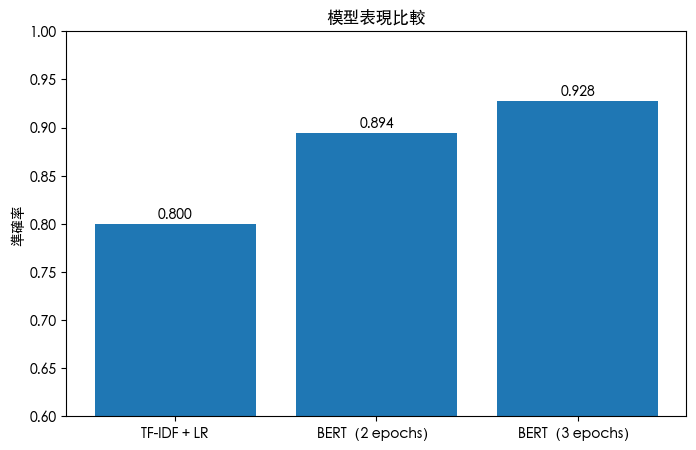

In [4]:
models = ["TF-IDF + LR", "BERT（2 epochs）", "BERT（3 epochs）"]
accuracy = [0.800, 0.894, 0.928]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.ylim(0.6, 1.0)
plt.ylabel("準確率")
plt.title("模型表現比較")

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center")

plt.show()

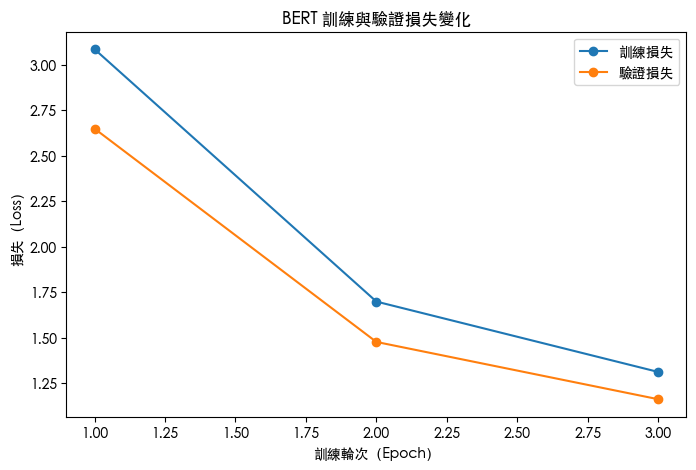

In [22]:
epochs = [1, 2, 3]
train_loss = [3.087, 1.699, 1.312]
val_loss = [2.650, 1.477, 1.162]

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker="o", label="訓練損失")
plt.plot(epochs, val_loss, marker="o", label="驗證損失")

plt.xlabel("訓練輪次（Epoch）")
plt.ylabel("損失（Loss）")
plt.title("BERT 訓練與驗證損失變化")
plt.legend()
plt.show()

In [29]:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_eval_bert, y_pred_eval_bert)

confusions = []

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i][j] > 0:
            confusions.append((i, j, cm[i][j]))

confusion_df = pd.DataFrame(
    confusions,
    columns=["真實類別", "預測類別", "錯誤次數"]
)

top_confused = confusion_df.sort_values(
    by="錯誤次數",
    ascending=False
).head(10)

print(top_confused)

    真實類別  預測類別  錯誤次數
98   111   112    11
74    93   104     7
0      0    26     6
51    71     7     6
25    31   110     6
19    21    24     5
31    40    97     4
53    73     3     4
18    20    45     4
52    71    83     3


In [30]:
intent_map = {
    i: label for i, label in enumerate(label_encoder.classes_)
}

intent_map

{0: 'accept_reservations',
 1: 'account_blocked',
 2: 'alarm',
 3: 'application_status',
 4: 'apr',
 5: 'are_you_a_bot',
 6: 'balance',
 7: 'bill_balance',
 8: 'bill_due',
 9: 'book_flight',
 10: 'book_hotel',
 11: 'calculator',
 12: 'calendar',
 13: 'calendar_update',
 14: 'calories',
 15: 'cancel',
 16: 'cancel_reservation',
 17: 'car_rental',
 18: 'card_declined',
 19: 'carry_on',
 20: 'change_accent',
 21: 'change_ai_name',
 22: 'change_language',
 23: 'change_speed',
 24: 'change_user_name',
 25: 'change_volume',
 26: 'confirm_reservation',
 27: 'cook_time',
 28: 'credit_limit',
 29: 'credit_limit_change',
 30: 'credit_score',
 31: 'current_location',
 32: 'damaged_card',
 33: 'date',
 34: 'definition',
 35: 'direct_deposit',
 36: 'directions',
 37: 'distance',
 38: 'do_you_have_pets',
 39: 'exchange_rate',
 40: 'expiration_date',
 41: 'find_phone',
 42: 'flight_status',
 43: 'flip_coin',
 44: 'food_last',
 45: 'freeze_account',
 46: 'fun_fact',
 47: 'gas',
 48: 'gas_type',
 49: '

In [39]:
import json

with open("../models/intent_classifier/id2label.json", "w", encoding="utf-8") as f:
    json.dump(intent_map, f, ensure_ascii=False, indent=2)

print("id2label.json saved successfully")

id2label.json saved successfully


In [32]:
import pandas as pd

confused_table = pd.DataFrame({
    "真實類別": [98, 74, 0, 51, 25],
    "預測類別": [111, 93, 26, 71, 31],
    "錯誤次數": [11, 7, 6, 6, 6]
})

intent_map = {0: 'accept_reservations',
 1: 'account_blocked',
 2: 'alarm',
 3: 'application_status',
 4: 'apr',
 5: 'are_you_a_bot',
 6: 'balance',
 7: 'bill_balance',
 8: 'bill_due',
 9: 'book_flight',
 10: 'book_hotel',
 11: 'calculator',
 12: 'calendar',
 13: 'calendar_update',
 14: 'calories',
 15: 'cancel',
 16: 'cancel_reservation',
 17: 'car_rental',
 18: 'card_declined',
 19: 'carry_on',
 20: 'change_accent',
 21: 'change_ai_name',
 22: 'change_language',
 23: 'change_speed',
 24: 'change_user_name',
 25: 'change_volume',
 26: 'confirm_reservation',
 27: 'cook_time',
 28: 'credit_limit',
 29: 'credit_limit_change',
 30: 'credit_score',
 31: 'current_location',
 32: 'damaged_card',
 33: 'date',
 34: 'definition',
 35: 'direct_deposit',
 36: 'directions',
 37: 'distance',
 38: 'do_you_have_pets',
 39: 'exchange_rate',
 40: 'expiration_date',
 41: 'find_phone',
 42: 'flight_status',
 43: 'flip_coin',
 44: 'food_last',
 45: 'freeze_account',
 46: 'fun_fact',
 47: 'gas',
 48: 'gas_type',
 49: 'goodbye',
 50: 'greeting',
 51: 'how_busy',
 52: 'how_old_are_you',
 53: 'improve_credit_score',
 54: 'income',
 55: 'ingredient_substitution',
 56: 'ingredients_list',
 57: 'insurance',
 58: 'insurance_change',
 59: 'interest_rate',
 60: 'international_fees',
 61: 'international_visa',
 62: 'jump_start',
 63: 'last_maintenance',
 64: 'lost_luggage',
 65: 'make_call',
 66: 'maybe',
 67: 'meal_suggestion',
 68: 'meaning_of_life',
 69: 'measurement_conversion',
 70: 'meeting_schedule',
 71: 'min_payment',
 72: 'mpg',
 73: 'new_card',
 74: 'next_holiday',
 75: 'next_song',
 76: 'no',
 77: 'nutrition_info',
 78: 'oil_change_how',
 79: 'oil_change_when',
 80: 'order',
 81: 'order_checks',
 82: 'order_status',
 83: 'pay_bill',
 84: 'payday',
 85: 'pin_change',
 86: 'play_music',
 87: 'plug_type',
 88: 'pto_balance',
 89: 'pto_request',
 90: 'pto_request_status',
 91: 'pto_used',
 92: 'recipe',
 93: 'redeem_rewards',
 94: 'reminder',
 95: 'reminder_update',
 96: 'repeat',
 97: 'replacement_card_duration',
 98: 'report_fraud',
 99: 'report_lost_card',
 100: 'reset_settings',
 101: 'restaurant_reservation',
 102: 'restaurant_reviews',
 103: 'restaurant_suggestion',
 104: 'rewards_balance',
 105: 'roll_dice',
 106: 'rollover_401k',
 107: 'routing',
 108: 'schedule_maintenance',
 109: 'schedule_meeting',
 110: 'share_location',
 111: 'shopping_list',
 112: 'shopping_list_update',
 113: 'smart_home',
 114: 'spelling',
 115: 'spending_history',
 116: 'sync_device',
 117: 'taxes',
 118: 'tell_joke',
 119: 'text',
 120: 'thank_you',
 121: 'time',
 122: 'timer',
 123: 'timezone',
 124: 'tire_change',
 125: 'tire_pressure',
 126: 'todo_list',
 127: 'todo_list_update',
 128: 'traffic',
 129: 'transactions',
 130: 'transfer',
 131: 'translate',
 132: 'travel_alert',
 133: 'travel_notification',
 134: 'travel_suggestion',
 135: 'uber',
 136: 'update_playlist',
 137: 'user_name',
 138: 'vaccines',
 139: 'w2',
 140: 'weather',
 141: 'what_are_your_hobbies',
 142: 'what_can_i_ask_you',
 143: 'what_is_your_name',
 144: 'what_song',
 145: 'where_are_you_from',
 146: 'whisper_mode',
 147: 'who_do_you_work_for',
 148: 'who_made_you',
 149: 'yes'}

confused_table["真實意圖"] = confused_table["真實類別"].map(intent_map)
confused_table["預測意圖"] = confused_table["預測類別"].map(intent_map)

print(confused_table)

confused_table_report = confused_table[["真實意圖","預測意圖","錯誤次數"]]
print(confused_table_report)

   真實類別  預測類別  錯誤次數                 真實意圖                 預測意圖
0    98   111    11         report_fraud        shopping_list
1    74    93     7         next_holiday       redeem_rewards
2     0    26     6  accept_reservations  confirm_reservation
3    51    71     6             how_busy          min_payment
4    25    31     6        change_volume     current_location
                  真實意圖                 預測意圖  錯誤次數
0         report_fraud        shopping_list    11
1         next_holiday       redeem_rewards     7
2  accept_reservations  confirm_reservation     6
3             how_busy          min_payment     6
4        change_volume     current_location     6


| 真實意圖                | 預測意圖                | 錯誤次數 |
| ------------------- | ------------------- | ---- |
| report_fraud        | shopping_list       | 11   |
| next_holiday        | redeem_rewards      | 7    |
| accept_reservations | confirm_reservation | 6    |
| how_busy            | min_payment         | 6    |
| change_volume       | current_location    | 6    |


為了分析模型錯誤來源，我整理了測試集中最常出現的錯誤分類情況（Top Confused Intents）。結果顯示部分意圖之間存在語意重疊，例如 intent 98 常被預測為 intent 111，共發生 11 次錯誤。這說明某些意圖之間的語義界線較模糊，是模型未來優化的方向。

/var/folders/wm/hk94xmkn7hl5_q0pjmp13vd40000gn/T/ipykernel_31833/1126452258.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  confused_table_report["錯誤類型"] = (


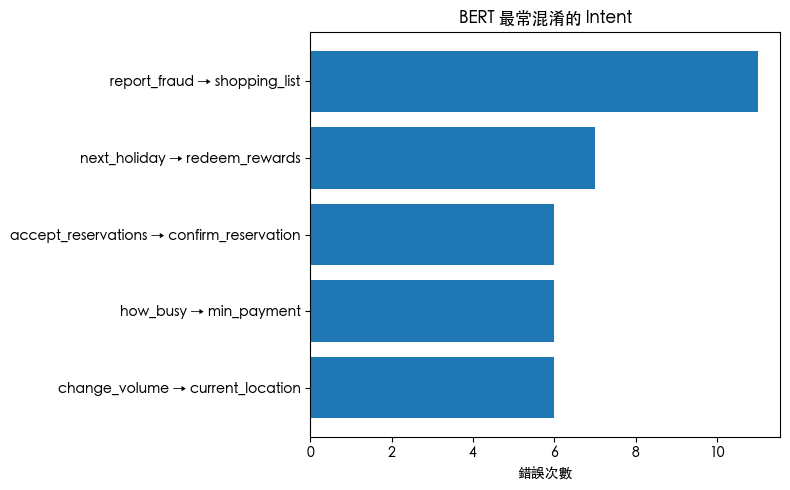

In [33]:
import matplotlib.pyplot as plt

# 建立 label
confused_table_report["錯誤類型"] = (
    confused_table_report["真實意圖"] + " → " + confused_table_report["預測意圖"]
)

plt.figure(figsize=(8,5))

plt.barh(
    confused_table_report["錯誤類型"],
    confused_table_report["錯誤次數"]
)

plt.xlabel("錯誤次數")
plt.title("BERT 最常混淆的 Intent")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

為了分析模型的錯誤來源，我整理了測試集中最常出現的錯誤分類情況。
結果顯示模型最常將 report_fraud 誤判為 shopping_list（11 次）。
其他常見錯誤包括 next_holiday → redeem_rewards 以及 accept_reservations → confirm_reservation。
這些錯誤多半來自語意相近或關鍵詞重疊的 intent。

雖然模型整體 Test Accuracy 為 92.8%，但從錯誤分析可以發現少數 intent pairs 仍存在語意混淆，未來可以透過增加訓練資料或重新設計 intent schema 來改善。

In [35]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true_eval_bert,
    y_pred_eval_bert,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

report_df.index = report_df.index.map(
    lambda x: intent_map[int(x)] if str(x).isdigit() else x
)

best_intents = report_df.iloc[:-3].sort_values(
    by="f1-score",
    ascending=False
).head(5)

print(best_intents)

worst_intents = report_df.iloc[:-3].sort_values(
    by="f1-score"
).head(5)

print(worst_intents)

               precision  recall  f1-score  support
uber                 1.0     1.0       1.0     20.0
pin_change           1.0     1.0       1.0     20.0
time                 1.0     1.0       1.0     20.0
change_volume        1.0     1.0       1.0     20.0
cook_time            1.0     1.0       1.0     20.0
                        precision  recall  f1-score  support
shopping_list            0.800000    0.40  0.533333     20.0
shopping_list_update     0.607143    0.85  0.708333     20.0
min_payment              1.000000    0.55  0.709677     20.0
restaurant_reservation   0.714286    0.75  0.731707     20.0
expiration_date          0.866667    0.65  0.742857     20.0


#### Intent Classification Model – Executive Insights
1. Model Performance Overview

本研究使用 BERT 進行多意圖分類（150 intents），並在測試資料集上評估模型表現。

Overall Test Performance

| Metric             | Value     |
| ------------------ | --------- |
| Test Accuracy      | **92.8%** |
| Macro F1-score     | **0.93**  |
| Total Test Samples | 3000      |

##### 商業解讀

整體而言，模型已能穩定識別大多數使用者意圖，準確率超過 90%，顯示 BERT 在理解多意圖對話語意方面具有良好效果。

2. Best Performing Intents

部分意圖在測試資料中達到幾乎完美的分類表現。

| Intent        | Precision | Recall | F1-score |
| ------------- | --------- | ------ | -------- |
| uber          | 1.00      | 1.00   | 1.00     |
| pin_change    | 1.00      | 1.00   | 1.00     |
| time          | 1.00      | 1.00   | 1.00     |
| change_volume | 1.00      | 1.00   | 1.00     |
| cook_time     | 1.00      | 1.00   | 1.00     |

##### 商業解讀

這些意圖的語意界線清晰，因此模型能夠穩定識別。
這類問題適合優先導入完全自動化客服或語音助理回應。

3. Challenging Intents

部分意圖仍存在分類困難。

| Intent                 | Precision | Recall   | F1-score |
| ---------------------- | --------- | -------- | -------- |
| shopping_list          | 0.80      | **0.40** | 0.53     |
| shopping_list_update   | 0.61      | 0.85     | 0.71     |
| min_payment            | 1.00      | **0.55** | 0.71     |
| restaurant_reservation | 0.71      | 0.75     | 0.73     |
| expiration_date        | 0.87      | 0.65     | 0.74     |

##### 商業解讀

較低的 F1-score 通常來自：

- 使用者語句語意相似

- intent 設計邊界不清

- 訓練資料樣本不足

例如：

shopping_list 的 recall 僅 0.40，表示模型漏掉約 60% 的相關請求。

4. Most Frequent Intent Confusions

為了解模型錯誤來源，我們分析了最常見的錯誤分類情況。

| True Intent         | Predicted Intent    | Error Count |
| ------------------- | ------------------- | ----------- |
| report_fraud        | shopping_list       | 11          |
| next_holiday        | redeem_rewards      | 7           |
| accept_reservations | confirm_reservation | 6           |
| how_busy            | min_payment         | 6           |
| change_volume       | current_location    | 6           |

##### 商業解讀

這些錯誤通常來自語意重疊，例如：

- reservation vs confirmation

- finance related intents

- list management intents

5. Key Business Insights

綜合模型結果，可以得到以下結論：

1. 模型整體可用性高

92.8% 的準確率顯示系統已具備部署潛力。

2. 多數意圖可自動處理

語意清晰的 intents 已能穩定識別，可直接應用於自動客服或語音助理。

3. 少數 intents 需要優化

部分意圖的分類困難來自語意重疊，未來可以透過：

- 增加訓練資料

- 合併相似 intents

- 改善 intent schema

- 來提升整體效果。